In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
df=pd.read_csv("Algerian_forest_fires_dataset_datanew.csv")
df_copy=df.copy()
df_copy.head()
df_copy.drop(["Unnamed: 0"],inplace=True,axis=1)
df_copy
df_copy.nunique()
df['Classes'].unique()
df_copy['Classes']=df_copy['Classes'].str.strip().str.lower()
df_copy['Classes'].unique()
df_copy
df_copy.drop(['day','month','year'],axis=1,inplace=True)
df_copy["Classes"] = df_copy["Classes"].map({"not fire": 0, "fire": 1})


df_copy['Classes'].value_counts()

,count
Classes,
1,137
0,106


## Classification Task: Predicting Fire or Not Fire

In [8]:
# Redefining independent and dependent features for classification
X_clf = df_copy.drop(['Classes'], axis=1) # FWI should be an independent feature for classification
y_clf = df_copy['Classes']

print("X_clf head:")
display(X_clf.head())
print("y_clf value counts:")
display(y_clf.value_counts())

X_clf head:


,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0


y_clf value counts:


,count
Classes,
1,137
0,106


### Train-Test Split for Classification

In [9]:
from sklearn.model_selection import train_test_split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.30, random_state=42, stratify=y_clf)

print(f"X_train_clf shape: {X_train_clf.shape}, y_train_clf shape: {y_train_clf.shape}")
print(f"X_test_clf shape: {X_test_clf.shape}, y_test_clf shape: {y_test_clf.shape}")

X_train_clf shape: (170, 11), y_train_clf shape: (170,)
X_test_clf shape: (73, 11), y_test_clf shape: (73,)


### Feature Selection based on Correlation (for Classification Features)

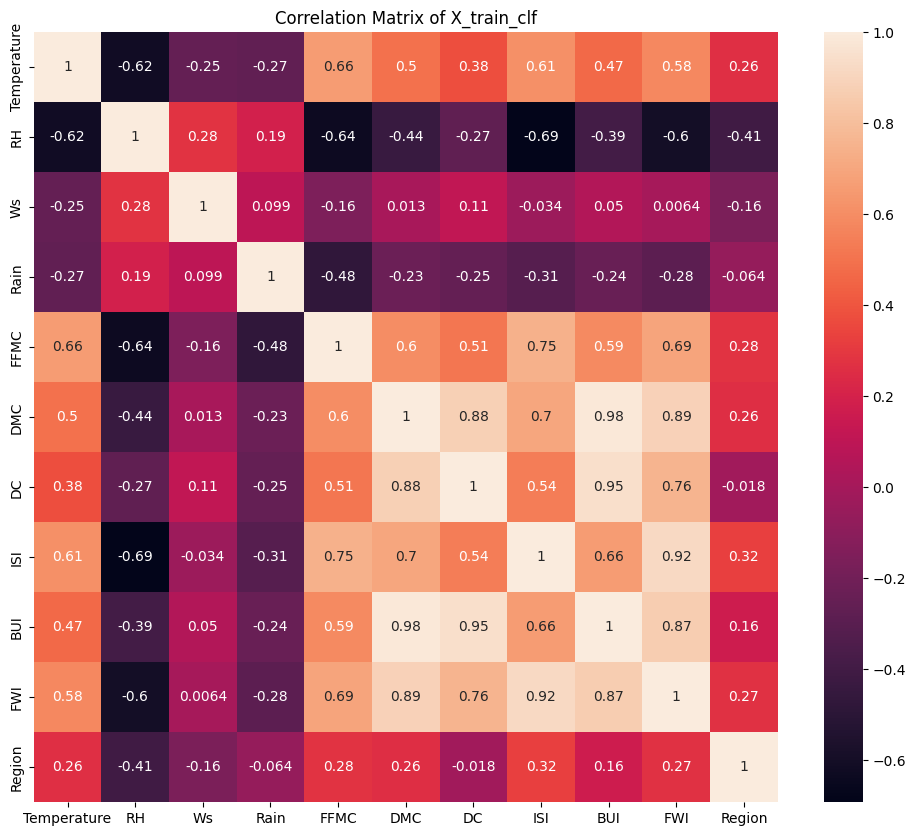

Highly correlated features to drop: {'FWI', 'BUI', 'DC'}
X_train_clf columns after dropping correlated features:


Index(['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'ISI', 'Region'], dtype='object')

In [10]:
# Reusing the correlation function defined earlier
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

plt.figure(figsize=(12,10))
corr_clf = X_train_clf.corr()
sns.heatmap(corr_clf, annot=True)
plt.title('Correlation Matrix of X_train_clf')
plt.show()

corr_features_clf = correlation(X_train_clf, 0.85)
print(f"Highly correlated features to drop: {corr_features_clf}")

# Drop the identified highly correlated features
X_train_clf.drop(corr_features_clf, axis=1, inplace=True)
X_test_clf.drop(corr_features_clf, axis=1, inplace=True)

print("X_train_clf columns after dropping correlated features:")
display(X_train_clf.columns)

### Feature Scaling for Classification Models

In [11]:
from sklearn.preprocessing import StandardScaler
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print("Shapes after scaling:")
print(f"X_train_clf_scaled: {X_train_clf_scaled.shape}")
print(f"X_test_clf_scaled: {X_test_clf_scaled.shape}")

Shapes after scaling:
X_train_clf_scaled: (170, 8)
X_test_clf_scaled: (73, 8)


### Classification Models Training and Evaluation


--- Training Logistic Regression ---
Accuracy: 0.9178
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90        32
           1       0.91      0.95      0.93        41

    accuracy                           0.92        73
   macro avg       0.92      0.91      0.92        73
weighted avg       0.92      0.92      0.92        73

Confusion Matrix:
[[28  4]
 [ 2 39]]


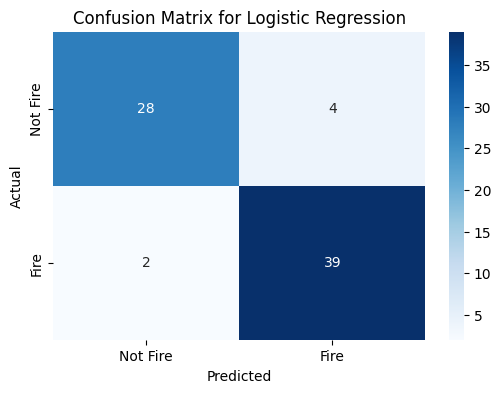


--- Training Decision Tree ---
Accuracy: 0.9589
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        32
           1       0.93      1.00      0.96        41

    accuracy                           0.96        73
   macro avg       0.97      0.95      0.96        73
weighted avg       0.96      0.96      0.96        73

Confusion Matrix:
[[29  3]
 [ 0 41]]


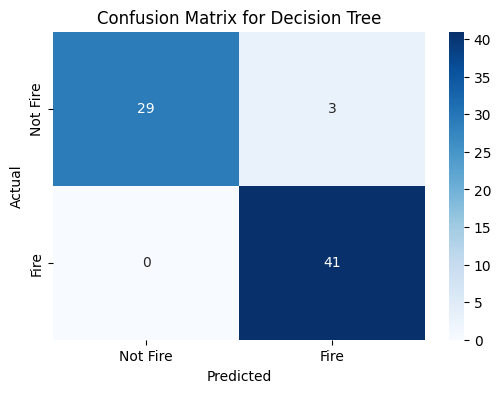


--- Training Support Vector Machine ---
Accuracy: 0.9315
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        32
           1       0.93      0.95      0.94        41

    accuracy                           0.93        73
   macro avg       0.93      0.93      0.93        73
weighted avg       0.93      0.93      0.93        73

Confusion Matrix:
[[29  3]
 [ 2 39]]


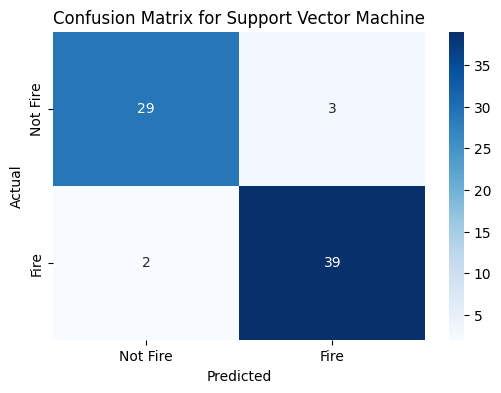

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),

    'Support Vector Machine': SVC(random_state=42)
}

results = {} # To store evaluation metrics

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train_clf_scaled, y_train_clf)
    y_pred_clf = model.predict(X_test_clf_scaled)

    accuracy = accuracy_score(y_test_clf, y_pred_clf)
    report = classification_report(y_test_clf, y_pred_clf)
    cm = confusion_matrix(y_test_clf, y_pred_clf)

    results[name] = {
        'Accuracy': accuracy,
        'Classification Report': report,
        'Confusion Matrix': cm
    }

    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(report)
    print("Confusion Matrix:")
    print(cm)

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fire', 'Fire'], yticklabels=['Not Fire', 'Fire'])
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

### Hyperparameter Tuning with GridSearchCV

In [14]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2']
    },
    'Decision Tree': {
        'max_depth': [None, 10, 20, 30],
        'min_samples_leaf': [1, 2, 4]
    },
    'Support Vector Machine': {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    }
}

best_models = {}

print("\n--- Hyperparameter Tuning ---\n")

for name, model in models.items():
    print(f"Tuning {name}...")
    grid_search = GridSearchCV(model, param_grids[name], cv=5, scoring='accuracy')
    grid_search.fit(X_train_clf_scaled, y_train_clf)

    best_models[name] = grid_search.best_estimator_

    print(f"Best parameters for {name}: {grid_search.best_params_}")
    print(f"Best cross-validation accuracy for {name}: {grid_search.best_score_:.4f}")
    print("\n" + "-"*30 + "\n")


--- Hyperparameter Tuning ---

Tuning Logistic Regression...
Best parameters for Logistic Regression: {'C': 0.1, 'penalty': 'l1'}
Best cross-validation accuracy for Logistic Regression: 0.9765

------------------------------

Tuning Decision Tree...
Best parameters for Decision Tree: {'max_depth': None, 'min_samples_leaf': 1}
Best cross-validation accuracy for Decision Tree: 0.9765

------------------------------

Tuning Support Vector Machine...
Best parameters for Support Vector Machine: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation accuracy for Support Vector Machine: 0.9588

------------------------------



### Evaluating Tuned Models


--- Evaluating Tuned Logistic Regression ---
Accuracy: 0.9726
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        32
           1       0.95      1.00      0.98        41

    accuracy                           0.97        73
   macro avg       0.98      0.97      0.97        73
weighted avg       0.97      0.97      0.97        73

Confusion Matrix:
[[30  2]
 [ 0 41]]


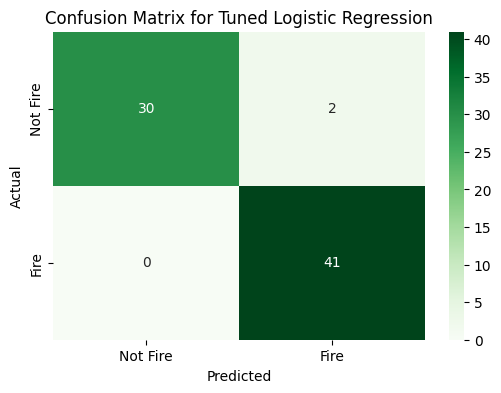


--- Evaluating Tuned Decision Tree ---
Accuracy: 0.9589
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        32
           1       0.93      1.00      0.96        41

    accuracy                           0.96        73
   macro avg       0.97      0.95      0.96        73
weighted avg       0.96      0.96      0.96        73

Confusion Matrix:
[[29  3]
 [ 0 41]]


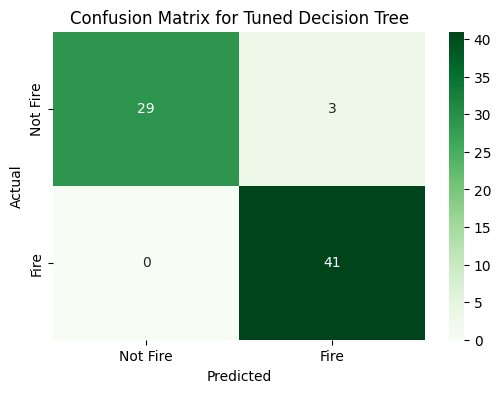


--- Evaluating Tuned Support Vector Machine ---
Accuracy: 0.9178
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        32
           1       0.93      0.93      0.93        41

    accuracy                           0.92        73
   macro avg       0.92      0.92      0.92        73
weighted avg       0.92      0.92      0.92        73

Confusion Matrix:
[[29  3]
 [ 3 38]]


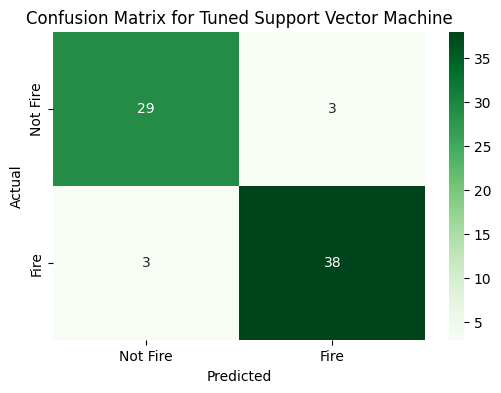

In [15]:
tuned_results = {}

for name, model in best_models.items():
    print(f"\n--- Evaluating Tuned {name} ---")
    y_pred_tuned = model.predict(X_test_clf_scaled)

    accuracy_tuned = accuracy_score(y_test_clf, y_pred_tuned)
    report_tuned = classification_report(y_test_clf, y_pred_tuned)
    cm_tuned = confusion_matrix(y_test_clf, y_pred_tuned)

    tuned_results[name] = {
        'Accuracy': accuracy_tuned,
        'Classification Report': report_tuned,
        'Confusion Matrix': cm_tuned
    }

    print(f"Accuracy: {accuracy_tuned:.4f}")
    print("Classification Report:")
    print(report_tuned)
    print("Confusion Matrix:")
    print(cm_tuned)

    # Plot Confusion Matrix for tuned models
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', xticklabels=['Not Fire', 'Fire'], yticklabels=['Not Fire', 'Fire'])
    plt.title(f'Confusion Matrix for Tuned {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

### Visualizing Model Performance